In [1]:
import os
import json
import time
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPUs: []


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT = Path.cwd()
PROJECT_ROOT = ROOT / "19042026"

E00_ROOT = PROJECT_ROOT / "E00_hyperparameter_tuning"
E02_ROOT = PROJECT_ROOT / "E02_class_imbalance"
E03_ROOT = PROJECT_ROOT / "E03_augmentation_overfitting"
EXP_ROOT = PROJECT_ROOT / "E04_finetuning_depth"

IMG_SIZE = (224, 224)
THRESHOLD = 0.50
BATCH_SIZE = 16

USE_HAIR_REMOVAL = True
USE_SEGMENTATION = True
USE_AUGMENTATION = True
AUG_MODE = "strong"   # best E03 result

# Time optimization:
# we reuse best E03 frozen result as reference baseline,
# so we only train the actual fine-tuning variants.
RUNS = [
    {
        "run_name": "E04_partial_unfreeze",
        "mode": "partial",
        "fine_tune_lr": 1e-5,
        "epochs": 8
    },
    {
        "run_name": "E04_deeper_unfreeze",
        "mode": "deeper",
        "fine_tune_lr": 5e-6,
        "epochs": 8
    }
]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("E00_ROOT:", E00_ROOT)
print("E02_ROOT:", E02_ROOT)
print("E03_ROOT:", E03_ROOT)
print("EXP_ROOT:", EXP_ROOT)

PROJECT_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026
E00_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E00_hyperparameter_tuning
E02_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E02_class_imbalance
E03_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E03_augmentation_overfitting
EXP_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E04_finetuning_depth


In [3]:
SUBDIRS = [
    "configs",
    "models",
    "histories",
    "metrics",
    "predictions",
    "plots",
    "confusion_matrices",
    "logs",
    "summary",
    "preprocessing_samples",
    "checkpoints"
]

for sub in SUBDIRS:
    (EXP_ROOT / sub).mkdir(parents=True, exist_ok=True)

for run in RUNS:
    run_name = run["run_name"]
    for sub in ["models", "histories", "metrics", "predictions", "plots", "confusion_matrices", "checkpoints"]:
        (EXP_ROOT / sub / run_name).mkdir(parents=True, exist_ok=True)

print("Folders ready.")

Folders ready.


In [4]:
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def verify_image(file_path):
    try:
        with Image.open(file_path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, IOError):
        return False

def remove_hairs_bgr(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    cleaned = cv2.inpaint(img_bgr, mask, 1, cv2.INPAINT_TELEA)
    return cleaned, mask

def simple_segment_lesion(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return img_bgr, thresh

    largest = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [largest], -1, 255, thickness=-1)

    segmented = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

    x, y, w, h = cv2.boundingRect(largest)
    crop = segmented[y:y+h, x:x+w] if w > 0 and h > 0 else segmented
    return crop, mask

def apply_augmentation(img_rgb, mode="strong"):
    h, w = img_rgb.shape[:2]

    if random.random() < 0.5:
        img_rgb = cv2.flip(img_rgb, 1)

    if mode == "strong":
        angle = random.uniform(-30, 30)
        scale = random.uniform(0.85, 1.15)
        tx = random.uniform(-0.08*w, 0.08*w)
        ty = random.uniform(-0.08*h, 0.08*h)
        alpha = random.uniform(0.85, 1.15)
        beta = random.uniform(-20, 20)
    else:
        angle = random.uniform(-20, 20)
        scale = random.uniform(0.90, 1.10)
        tx = random.uniform(-0.05*w, 0.05*w)
        ty = random.uniform(-0.05*h, 0.05*h)
        alpha = random.uniform(0.90, 1.10)
        beta = random.uniform(-15, 15)

    M = cv2.getRotationMatrix2D((w//2, h//2), angle, scale)
    M[:, 2] += [tx, ty]
    img_rgb = cv2.warpAffine(img_rgb, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
    img_rgb = cv2.convertScaleAbs(img_rgb, alpha=alpha, beta=beta)
    return img_rgb

def preprocess_image_for_resnet(path, img_size=(224, 224), use_hair_removal=True, use_segmentation=True, use_aug=False, aug_mode="strong"):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")

    original = img_bgr.copy()
    hair_mask = None
    seg_mask = None

    if use_hair_removal:
        img_bgr, hair_mask = remove_hairs_bgr(img_bgr)

    if use_segmentation:
        img_bgr, seg_mask = simple_segment_lesion(img_bgr)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, img_size, interpolation=cv2.INTER_AREA)

    if use_aug:
        img_rgb = apply_augmentation(img_rgb, mode=aug_mode)

    img_arr = np.asarray(img_rgb, dtype=np.float32)
    img_arr = preprocess_input(img_arr)

    return img_arr, original, hair_mask, seg_mask

def evaluate_binary(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    try:
        roc = roc_auc_score(y_true, y_prob)
    except:
        roc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "kappa": float(kappa),
        "roc_auc": float(roc) if not np.isnan(roc) else None,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold)
    }

def plot_confusion(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    labels = ["Non-Melanoma", "Melanoma"]
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(2))
    ax.set_yticks(range(2))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

def plot_history(history, save_dir, run_name):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 5))
    plt.plot(hist["accuracy"], label="Train Accuracy")
    plt.plot(hist["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_accuracy.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(7, 5))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_loss.png", dpi=300, bbox_inches="tight")
    plt.close()

def plot_roc_pr(y_true, y_prob, save_dir, run_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_roc.png", dpi=300, bbox_inches="tight")
    plt.close()

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_pr.png", dpi=300, bbox_inches="tight")
    plt.close()

In [5]:
best_cfg = load_json(E00_ROOT / "summary" / "best_config.json")
best_hparams = best_cfg["best_config"]

best_e02 = load_json(E02_ROOT / "summary" / "best_E02_variant.json")
best_e03 = load_json(E03_ROOT / "summary" / "best_E03_variant.json")
manifest_e02 = load_json(E02_ROOT / "summary" / "experiment_manifest.json")

cb_class_weights = {int(k): float(v) for k, v in manifest_e02["class_balanced_weights"].items()}

train_df = pd.read_csv(E00_ROOT / "summary" / "train_split.csv")
val_df   = pd.read_csv(E00_ROOT / "summary" / "val_split.csv")
test_df  = pd.read_csv(E00_ROOT / "summary" / "test_split.csv")

train_df["image_path"] = train_df["image_path"].apply(Path)
val_df["image_path"] = val_df["image_path"].apply(Path)
test_df["image_path"] = test_df["image_path"].apply(Path)

print("Best E00 config:")
print(json.dumps(best_cfg, indent=4))

print("\nBest E02 variant:")
print(json.dumps(best_e02, indent=4))

print("\nBest E03 variant:")
print(json.dumps(best_e03, indent=4))

print("\nClass-balanced weights from E02:")
print(cb_class_weights)

Best E00 config:
{
    "best_by": "f1",
    "sort_column": "test_f1",
    "best_run_name": "run_004_du256_do04_lr5e-05_bs16",
    "best_config": {
        "dense_units": 256,
        "dropout": 0.4,
        "lr": 5e-05,
        "batch_size": 16,
        "epochs": 15
    },
    "best_test_metrics": {
        "accuracy": 0.982874617737003,
        "precision": 0.75,
        "recall": 0.05172413793103448,
        "f1": 0.0967741935483871,
        "kappa": 0.0947022879629813,
        "roc_auc": 0.8362176321552798,
        "tn": 3211,
        "fp": 1,
        "fn": 55,
        "tp": 3
    }
}

Best E02 variant:
{
    "run_name": "E02_class_balanced_bce",
    "mode": "class_balanced_bce",
    "source_e01_run": "E01b_baseline_segmented",
    "accuracy": 0.9596330275229358,
    "precision": 0.12244897959183673,
    "recall": 0.20689655172413793,
    "f1": 0.15384615384615385,
    "kappa": 0.1345598614140896,
    "roc_auc": 0.8305707046850174,
    "tn": 3126,
    "fp": 86,
    "fn": 46,
    "tp

In [6]:
sample_df = train_df.sample(min(6, len(train_df)), random_state=SEED)

for run in RUNS:
    run_name = run["run_name"]

    out_dir = EXP_ROOT / "preprocessing_samples" / run_name
    out_dir.mkdir(parents=True, exist_ok=True)

    for idx, row in sample_df.iterrows():
        _, original_bgr, hair_mask, seg_mask = preprocess_image_for_resnet(
            row["image_path"],
            img_size=IMG_SIZE,
            use_hair_removal=USE_HAIR_REMOVAL,
            use_segmentation=USE_SEGMENTATION,
            use_aug=True,
            aug_mode=AUG_MODE
        )

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(hair_mask, cmap="gray")
        axes[1].set_title("Hair Mask")
        axes[1].axis("off")

        axes[2].imshow(seg_mask, cmap="gray")
        axes[2].set_title("Segmentation Mask")
        axes[2].axis("off")

        plt.tight_layout()
        plt.savefig(out_dir / f"sample_{idx}.png", dpi=300, bbox_inches="tight")
        plt.close()

In [7]:
def make_tf_dataset(df_split, shuffle=False, batch_size=16, use_aug=False):
    paths = df_split["image_path"].astype(str).values
    labels = df_split["target"].astype(np.float32).values

    def _load(path, label):
        def _py_load(p, y):
            p = p.decode("utf-8")
            img_arr, _, _, _ = preprocess_image_for_resnet(
                p,
                img_size=IMG_SIZE,
                use_hair_removal=USE_HAIR_REMOVAL,
                use_segmentation=USE_SEGMENTATION,
                use_aug=use_aug,
                aug_mode=AUG_MODE
            )
            return img_arr.astype(np.float32), np.float32(y)

        image, lbl = tf.numpy_function(_py_load, [path, label], [tf.float32, tf.float32])
        image.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
        lbl.set_shape(())
        return image, tf.expand_dims(lbl, axis=-1)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df_split), 2048), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [8]:
best_e03_model_path = E03_ROOT / "models" / best_e03["run_name"] / f"{best_e03['run_name']}.keras"
if not best_e03_model_path.exists():
    raise FileNotFoundError(f"Best E03 model not found: {best_e03_model_path}")

best_e03_head = keras.models.load_model(best_e03_model_path)

def set_trainable_depth(base_model, mode="partial"):
    # Freeze everything first
    for layer in base_model.layers:
        layer.trainable = False

    # Keep BatchNorm frozen for stability
    if mode == "partial":
        for layer in base_model.layers:
            if layer.name.startswith("conv5_") and not isinstance(layer, layers.BatchNormalization):
                layer.trainable = True

    elif mode == "deeper":
        for layer in base_model.layers:
            if (layer.name.startswith("conv4_") or layer.name.startswith("conv5_")) and not isinstance(layer, layers.BatchNormalization):
                layer.trainable = True

def build_finetune_model(mode="partial", lr=1e-5):
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    set_trainable_depth(base_model, mode=mode)

    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs, training=True)
    x = layers.Dense(best_hparams["dense_units"], activation="relu", name="ft_dense")(x)
    x = layers.Dropout(best_hparams["dropout"], name="ft_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="ft_output")(x)

    model = keras.Model(inputs, outputs)

    # initialize head from best E03 cached-feature model
    src_layers = [layer for layer in best_e03_head.layers if isinstance(layer, layers.Dense)]
    dst_dense = model.get_layer("ft_dense")
    dst_out = model.get_layer("ft_output")

    dst_dense.set_weights(src_layers[0].get_weights())
    dst_out.set_weights(src_layers[1].get_weights())

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    trainable_count = np.sum([np.prod(v.shape) for v in model.trainable_weights])
    print(f"Mode={mode}, trainable params={trainable_count:,}")
    return model

In [9]:
train_ds = make_tf_dataset(train_df, shuffle=True, batch_size=BATCH_SIZE, use_aug=True)
val_ds   = make_tf_dataset(val_df, shuffle=False, batch_size=BATCH_SIZE, use_aug=False)
test_ds  = make_tf_dataset(test_df, shuffle=False, batch_size=BATCH_SIZE, use_aug=False)

print("Datasets ready.")

Datasets ready.


In [10]:
all_results = []

# Reuse best E03 as frozen reference baseline for comparison
frozen_reference_row = {
    "run_name": "E04_reference_frozen_from_E03",
    "mode": "frozen_reference",
    "source_e03_run": best_e03["run_name"],
    "accuracy": best_e03["accuracy"],
    "precision": best_e03["precision"],
    "recall": best_e03["recall"],
    "f1": best_e03["f1"],
    "kappa": best_e03["kappa"],
    "roc_auc": best_e03["roc_auc"],
    "tn": best_e03["tn"],
    "fp": best_e03["fp"],
    "fn": best_e03["fn"],
    "tp": best_e03["tp"],
    "runtime_sec": best_e03["runtime_sec"]
}
all_results.append(frozen_reference_row)

print("Frozen reference from E03 added.")

Frozen reference from E03 added.


In [11]:
for run in RUNS:
    run_name = run["run_name"]
    mode = run["mode"]
    fine_tune_lr = run["fine_tune_lr"]
    epochs = run["epochs"]

    print("\n" + "=" * 90)
    print("Running:", run_name)
    print("Mode:", mode)
    print("LR:", fine_tune_lr)
    print("Epochs:", epochs)

    run_start = time.time()

    model = build_finetune_model(mode=mode, lr=fine_tune_lr)

    checkpoint_path = EXP_ROOT / "checkpoints" / run_name / f"{run_name}_best.keras"

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1,
        callbacks=callbacks,
        class_weight=cb_class_weights
    )

    runtime_sec = time.time() - run_start

    model.save(EXP_ROOT / "models" / run_name / f"{run_name}.keras")

    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(EXP_ROOT / "histories" / run_name / f"{run_name}_history.csv", index=False)
    plot_history(history, EXP_ROOT / "plots" / run_name, run_name)

    y_val = val_df["target"].values.astype(int)
    y_test = test_df["target"].values.astype(int)

    y_val_prob = model.predict(val_ds, verbose=0).ravel()
    y_test_prob = model.predict(test_ds, verbose=0).ravel()

    val_metrics = evaluate_binary(y_val, y_val_prob, threshold=THRESHOLD)
    test_metrics = evaluate_binary(y_test, y_test_prob, threshold=THRESHOLD)

    pred_df = pd.DataFrame({
        "image_name": test_df["image_name"].values,
        "true_label": y_test,
        "pred_prob": y_test_prob,
        "pred_label": (y_test_prob >= THRESHOLD).astype(int)
    })
    pred_df.to_csv(EXP_ROOT / "predictions" / run_name / f"{run_name}_test_predictions.csv", index=False)

    metrics_package = {
        "run_name": run_name,
        "mode": mode,
        "source_e03_run": best_e03["run_name"],
        "fine_tune_lr": fine_tune_lr,
        "epochs": epochs,
        "best_hyperparameters_from_E00": best_hparams,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "runtime_sec": round(runtime_sec, 2)
    }
    save_json(metrics_package, EXP_ROOT / "metrics" / run_name / f"{run_name}_metrics.json")

    cm = confusion_matrix(y_test, (y_test_prob >= THRESHOLD).astype(int), labels=[0, 1])
    plot_confusion(
        cm,
        title=f"Confusion Matrix - {run_name}",
        save_path=EXP_ROOT / "confusion_matrices" / run_name / f"{run_name}_cm.png"
    )

    plot_roc_pr(y_test, y_test_prob, EXP_ROOT / "plots" / run_name, run_name)

    row = {
        "run_name": run_name,
        "mode": mode,
        "source_e03_run": best_e03["run_name"],
        "accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "kappa": test_metrics["kappa"],
        "roc_auc": test_metrics["roc_auc"],
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
        "runtime_sec": round(runtime_sec, 2)
    }
    all_results.append(row)

results_df = pd.DataFrame(all_results)
results_df.to_csv(EXP_ROOT / "summary" / "E04_results_comparison.csv", index=False)
results_df


Running: E04_partial_unfreeze
Mode: partial
LR: 1e-05
Epochs: 8
Mode=partial, trainable params=15,478,273
Epoch 1/8
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9019 - loss: 0.0607
Epoch 1: val_loss improved from inf to 0.30882, saving model to C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E04_finetuning_depth\checkpoints\E04_partial_unfreeze\E04_partial_unfreeze_best.keras
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 10136s 6s/step - accuracy: 0.9019 - loss: 0.0607 - val_accuracy: 0.8535 - val_loss: 0.3088
Epoch 2/8
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8967 - loss: 0.0542
Epoch 2: val_loss improved from 0.30882 to 0.15334, saving model to C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E04_finetuning_depth\checkpoints\E04_partial_unfreeze\E04_partial_unfreeze_best.keras
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 9577s 6s/step - accuracy: 0.8967 - loss: 0.0542 - val_accuracy: 0.9547 - v

,run_name,mode,source_e03_run,accuracy,precision,recall,f1,kappa,roc_auc,tn,fp,fn,tp,runtime_sec
0,E04_reference_frozen_from_E03,frozen_reference,E03_aug_strong,0.963914,0.142857,0.206897,0.169014,0.151202,0.836446,3140,72,46,12,23039.34
1,E04_partial_unfreeze,partial,E03_aug_strong,0.954434,0.104348,0.206897,0.138728,0.117928,0.828815,3109,103,46,12,46056.62
2,E04_deeper_unfreeze,deeper,E03_aug_strong,0.930887,0.088235,0.310345,0.137405,0.112902,0.848193,3026,186,40,18,39243.58


In [12]:
results_sorted = results_df.sort_values(by=["f1", "recall", "kappa"], ascending=False).reset_index(drop=True)
best_e04 = results_sorted.iloc[0].to_dict()

save_json(best_e04, EXP_ROOT / "summary" / "best_E04_variant.json")

print("Best E04 variant:")
print(json.dumps(best_e04, indent=4))

Best E04 variant:
{
    "run_name": "E04_reference_frozen_from_E03",
    "mode": "frozen_reference",
    "source_e03_run": "E03_aug_strong",
    "accuracy": 0.963914373088685,
    "precision": 0.14285714285714285,
    "recall": 0.20689655172413793,
    "f1": 0.16901408450704225,
    "kappa": 0.151202386294644,
    "roc_auc": 0.8364457637308369,
    "tn": 3140,
    "fp": 72,
    "fn": 46,
    "tp": 12,
    "runtime_sec": 23039.34
}


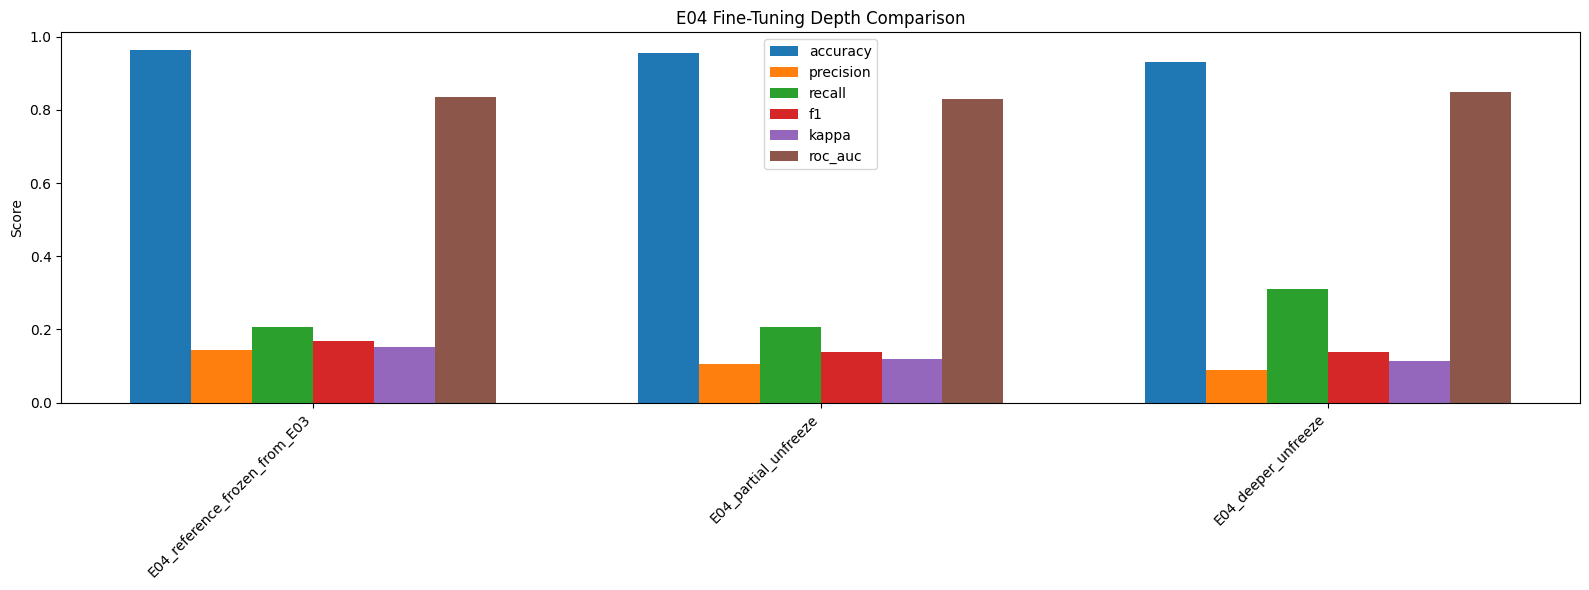

In [13]:
if len(results_df) > 0:
    plot_cols = ["accuracy", "precision", "recall", "f1", "kappa", "roc_auc"]
    plot_df = results_df[["run_name"] + plot_cols].copy()

    x = np.arange(len(plot_df))
    width = 0.12

    plt.figure(figsize=(16, 6))
    for idx, col in enumerate(plot_cols):
        plt.bar(x + idx * width, plot_df[col].fillna(0), width=width, label=col)

    plt.xticks(x + width * (len(plot_cols)-1) / 2, plot_df["run_name"], rotation=45, ha="right")
    plt.ylabel("Score")
    plt.title("E04 Fine-Tuning Depth Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(EXP_ROOT / "plots" / "E04_metrics_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

In [14]:
manifest = {
    "experiment_id": "E04",
    "experiment_name": "Fine-Tuning Depth",
    "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "project_root": str(PROJECT_ROOT),
    "experiment_root": str(EXP_ROOT),
    "source_e03_run": best_e03["run_name"],
    "best_hyperparameters_from_E00": best_hparams,
    "best_e02_variant": best_e02,
    "class_balanced_weights_from_E02": cb_class_weights,
    "threshold": THRESHOLD,
    "use_hair_removal": USE_HAIR_REMOVAL,
    "use_segmentation": USE_SEGMENTATION,
    "use_augmentation": USE_AUGMENTATION,
    "augmentation_mode": AUG_MODE,
    "runs": RUNS,
    "note": "Frozen baseline reused from best E03 to save time; only actual fine-tuning variants were trained."
}
save_json(manifest, EXP_ROOT / "summary" / "experiment_manifest.json")
print("E04 finished.")

E04 finished.
